In [122]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import sys
from scipy.stats import norm, poisson, chi2
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [123]:
R1 = 4666 #ohm
Catteso=104e-9 #F
V0=1
tau_A = R1*Catteso #tau atteso : R * C

In [124]:
def RC_dec(t, V0, tau):
    return V0*np.e**(-t/tau)

In [125]:
def RL_cre(t, V0, tau):
    return V0*(1-np.e**(-t/tau))

In [126]:
with open('C2RC.txt') as input_file:
    tlist = []
    errtlist = []
    Vlist = []
    errVlist = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        tlist.append(float(valori[0]))
        errtlist.append(float(valori[1]))
        Vlist.append(float(valori[2]))
        errVlist.append(float(valori[3]))

t_fit = np.array(tlist)
V_fit = np.array(Vlist)
errt_fit = np.array(errtlist)
errV_fit = np.array(errVlist)

# scegli il tratto che vuoi fittare
#Vd_fit = Vd[113:130] #confa: [36:55]
#Id_fit = Id[113:130] #confb: [56:75]


err_tot=[]
for i in range(len(V_fit)):
    err_tot.append(np.sqrt((errV_fit[i]**2)+(errt_fit[i]**2)))

print (err_tot)


['0.000158', '0.000001', '4.7', '0.04']
['0.00029', '0.000001', '3.6', '0.04']
['0.00045', '0.000001', '2.46', '0.04']
['0.00061', '0.000001', '1.8', '0.02']
['0.00069', '0.000001', '1.52', '0.02']
['0.00077', '0.000001', '1.28', '0.02']
['0.00085', '0.000001', '1.12', '0.04']
['0.00093', '0.000001', '0.94', '0.02']
['0.00101', '0.000001', '0.8', '0.02']
['0.00109', '0.000001', '0.68', '0.02']
['0.00117', '0.000001', '0.578', '0.02']
['0.00125', '0.000001', '0.5', '0.01']
['0.00141', '0.000001', '0.34', '0.02']
['0.00149', '0.000001', '0.32', '0.02']
['0.00157', '0.000001', '0.24', '0.02']
['0.00165', '0.000001', '0.2', '0.02']
['0.00181', '0.000001', '0.16', '0.02']
[np.float64(0.0400000000125), np.float64(0.0400000000125), np.float64(0.0400000000125), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.0400000000125), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(

In [127]:
least_square = LeastSquares(t_fit, V_fit, err_tot, RC_dec)

my_minuit = Minuit(least_square, tau=0, V0=0)
my_minuit.limits['tau'] = (1e-5, 3e-2)
my_minuit.limits['V0'] = (1, 7)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

tau_fit = my_minuit.values['tau']
tau_err = my_minuit.errors['tau']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  17.803177621463696
value of the number of degrees of freedom:  15.0
associated p-value:  0.273154468026102
V0 = 6.474501e+00 +/- 5.291157e-02
tau = 4.809871e-04 +/- 2.936159e-06
┌─────┬─────────────────────────┐
│     │          V0         tau │
├─────┼─────────────────────────┤
│  V0 │      0.0028 -131.905e-9 │
│ tau │ -131.905e-9    8.62e-12 │
└─────┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 17.8 (χ²/ndof = 1.2)       │              Nfcn = 101              │
│ EDM = 4.35e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │   6.47    │   0.05    │            │            │    1    │    7    │       │
│ 1 │ tau  │ 481.0e-6  │  2.9e-6   │            │            │  1e-05  │  0.03   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────┐
│     │          V0         tau │
├─────┼─────────────────────────┤
│  V0 │      0.0028 -131.905e-9 │
│ tau │ -131.905e-9    8.62e-12 │
└─────┴─────────────────────────┘

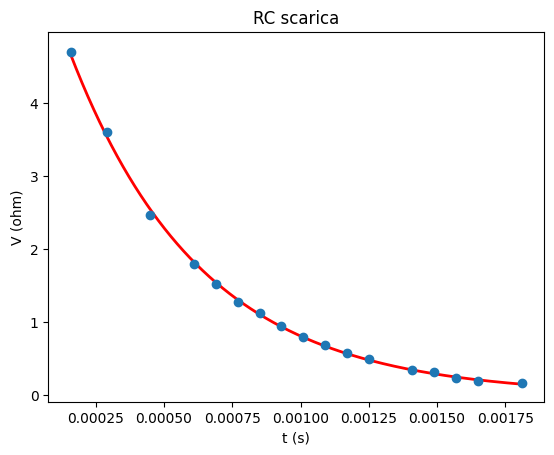

In [128]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="red", linewidth=2)
    ax.set_xlabel ("t (s)")
    ax.set_ylabel ("V (ohm)")
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    plt.show()
    #plt.close(fig)
plot_fit(t_fit,V_fit, err_tot ,RC_dec, my_minuit, "RC scarica")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [129]:
print ('tau:',tau_fit, '+/-', tau_err, 'V0:', V0_fit, '+/-', V0_err)

tau: 0.0004809870605298347 +/- 2.9361585978555113e-06 V0: 6.474500768969241 +/- 0.05291156916675144


In [130]:
t_student_tau = (tau_A - tau_fit)/tau_err
print(t_student_tau)

1.4566445672549997


In [131]:
C=tau_fit/R1
print(C)

1.0308338202525391e-07


In [132]:
R = 4.666 #kohm
#L=  #H quella che abbiamo usato
V0=1
tau_A = 4,85472*10^-4 #tau atteso : L/R

In [133]:
with open('C2RL.txt') as input_file:
    t1list = []
    errt1list = []
    V1list = []
    errV1list = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        t1list.append(float(valori[0]))
        errt1list.append(float(valori[1]))
        V1list.append(float(valori[2]))
        errV1list.append(float(valori[3]))

t1_fit = np.array(t1list)
V1_fit = np.array(V1list)
errt1_fit = np.array(errt1list)
errV1_fit = np.array(errV1list)

errtot=[]
for i in range(len(V1_fit)):
    errtot.append(np.sqrt((errV1_fit[i]**2)+(errt1_fit[i]**2)))

print (errtot)

['0.00000209', '0.000001', '4.4', '0.1']
['0.00000229', '0.000001', '4.85', '0.1']
['0.00000249', '0.000001', '5.25', '0.1']
['0.00000269', '0.000001', '5.6', '0.1']
['0.00000289', '0.000001', '5.92', '0.1']
['0.00000329', '0.000001', '6.48', '0.1']
['0.00000389', '0.000001', '7.13', '0.1']
['0.00000409', '0.000001', '7.32', '0.1']
['0.00000469', '0.000001', '7.77', '0.1']
['0.00000489', '0.000001', '7.92', '0.1']
['0.00000549', '0.000001', '8.24', '0.1']
[np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005)]


In [134]:
least_square = LeastSquares(t1_fit, V1_fit, errtot, RL_cre)

my_minuit = Minuit(least_square, tau=0, V0=0)
my_minuit.limits['tau'] = (1e-6, 9e-6)
my_minuit.limits['V0'] = (0, 15)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

tau_fit = my_minuit.values['tau']
tau_err = my_minuit.errors['tau']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  13.330766652964265
value of the number of degrees of freedom:  9.0
associated p-value:  0.1482016474962764
V0 = 1.100630e+01 +/- 3.145936e-01
tau = 3.827781e-06 +/- 1.865066e-07
┌─────┬───────────────────────────┐
│     │           V0          tau │
├─────┼───────────────────────────┤
│  V0 │        0.099 57.956808e-9 │
│ tau │ 57.956808e-9     3.48e-14 │
└─────┴───────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 13.33 (χ²/ndof = 1.5)      │              Nfcn = 162              │
│ EDM = 8.4e-06 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │   11.01   │   0.32    │            │            │    0    │   15    │       │
│ 1 │ tau  │  3.83e-6  │  0.19e-6  │            │            │  1e-06  │  9e-06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────────────────────────┐
│     │           V0          tau │
├─────┼───────────────────────────┤
│  V0 │        0.099 57.956808e-9 │
│ tau │ 57.956808e-9     3.48e-14 │
└─────┴───────────────────────────┘

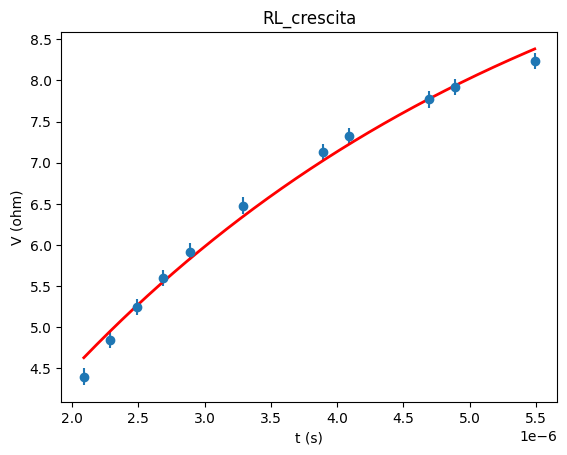

In [135]:
plot_fit(t1_fit,V1_fit, errtot ,RL_cre, my_minuit, "RL_crescita")
#plt.savefig("RL scarica.png")
plt.show()
#plt.close(fig)

In [136]:
#stima di L
L= tau_fit*R
print('induttanza misurata: ' ,L, 'H')

induttanza misurata:  1.786042544114515e-05 H


In [137]:
#parte 2

In [138]:
Rcr= 500
alfa= Rcr/(2*L)
def RLC_critico(t, V0, alpha):
    return V0 * (1 - np.exp(-alpha * t) * (1 + alpha * t))
print(alfa)

13997426.927136559


In [139]:
#stima di Rcirucito critico
#Rcritica= 2*np.sqrt(L/C)
#print('resistenza interna circuito RLC critico: ', Rc, 'ohm')

In [140]:
#parte di prova
#Lc= (500**2)*C/4
#Ratt=Lc/tau_fit
#Ldiff = Lc-L
#print(Lc, Ratt)

In [141]:
with open('C2RLCcritico.txt') as input_file:
    t2list = []
    errt2list = []
    V2list = []
    errV2list = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        t2list.append(float(valori[0]))
        errt2list.append(float(valori[1]))
        V2list.append(float(valori[2]))
        errV2list.append(float(valori[3]))

t2_fit = np.array(t2list)
V2_fit = np.array(V2list)
errt2_fit = np.array(errt2list)
errV2_fit = np.array(errV2list)

err__tot=[]
for i in range(len(V2_fit)):
    err__tot.append(np.sqrt((errV2_fit[i]**2)+(errt2_fit[i]**2)))

print (err__tot)

['0.00000184', '0.00000001', '1.08', '0.01']
['0.00000584', '0.00000001', '2.88', '0.04']
['0.0000138', '0.00000001', '5.36', '0.04']
['0.0000198', '0.00000001', '6.4', '0.04']
['0.0000258', '0.00000001', '7.04', '0.04']
['0.0000318', '0.00000001', '7.28', '0.04']
['0.0000398', '0.00000001', '7.2', '0.04']
['0.0000458', '0.00000001', '6.96', '0.04']
['0.0000518', '0.00000001', '6.56', '0.04']
['0.0000618', '0.00000001', '5.76', '0.04']
['0.0000678', '0.00000001', '5.28', '0.04']
['0.0000806', '0.00000001', '4.16', '0.04']
['0.0000926', '0.00000001', '3.28', '0.04']
['0.000104', '0.00000001', '2.52', '0.04']
['0.000132', '0.00000001', '1.24', '0.04']
['0.000156', '0.00000001', '0.6', '0.04']
['0.000184', '0.00000001', '0.28', '0.04']
[np.float64(0.010000000000005), np.float64(0.04000000000000125), np.float64(0.04000000000000125), np.float64(0.04000000000000125), np.float64(0.04000000000000125), np.float64(0.04000000000000125), np.float64(0.04000000000000125), np.float64(0.04000000000000

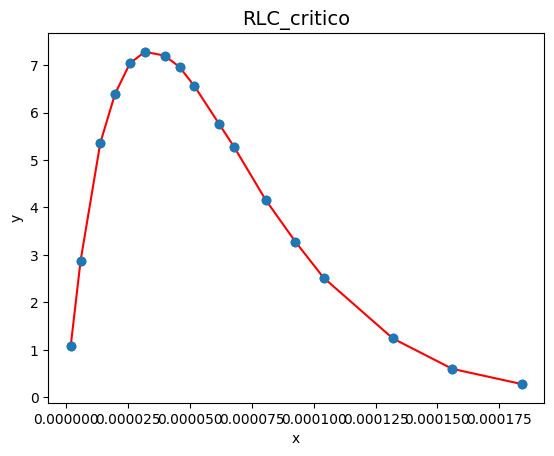

In [142]:
fig, ax = plt.subplots (nrows = 1, ncols = 1) # crea il grafico
ax.set_title ('RLC_critico', size=14)
ax.set_xlabel ('x')
ax.set_ylabel ('y')
ax.errorbar (t2_fit, V2_fit, xerr = 0.0, yerr = err__tot, linestyle = 'None', marker = 'o') #disegna punti con errori
ax.plot (t2_fit, V2_fit, color='red', label='sin(x)') # disegna grafico normale
ax.scatter(t2_fit, V2_fit, marker = 'o') # disegna solo i punti

In [143]:
least_square = LeastSquares(t2_fit, V2_fit, err__tot, RLC_critico)

my_minuit = Minuit(least_square, alpha=0, V0=0)
my_minuit.limits['alpha'] = (4e5, 5e5)
my_minuit.limits['V0'] = (4.6, 7.5)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

alpha_fit = my_minuit.values['alpha']
alpha_err = my_minuit.errors['alpha']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  54814.22732218975
value of the number of degrees of freedom:  15.0
associated p-value:  0.0
V0 = 4.641046e+00 +/- 1.032386e-02
alpha = 4.800254e+05 +/- 3.180747e+03
┌───────┬───────────────────┐
│       │       V0    alpha │
├───────┼───────────────────┤
│    V0 │ 0.000107 -9.43637 │
│ alpha │ -9.43637 1.01e+07 │
└───────┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.481e+04 (χ²/ndof = 3654.3)│              Nfcn = 93               │
│ EDM = 5.09e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0    │   4.641   │   0.010   │            │            │   4.6   │   7.5   │       │
│ 1 │ alpha │  480.0e3  │   3.2e3   │            │            │ 400000  │ 500000  │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │       V0    alpha │
├───────┼───────────────────┤
│    V0 │ 0.000107 -9.43637 │
│ alpha │ -9.43637 1.01e+07 │
└───────┴───────────────────┘

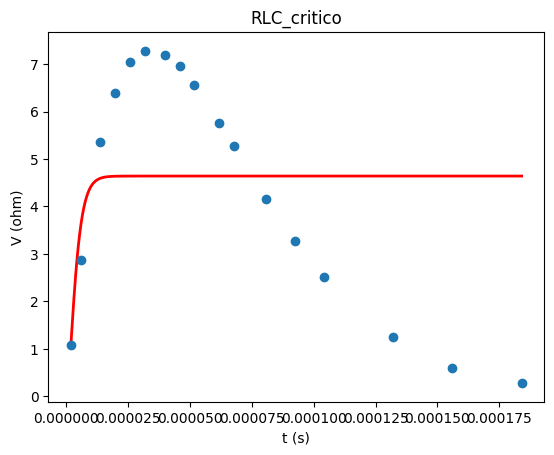

In [144]:
plot_fit(t2_fit,V2_fit, err__tot ,RLC_critico, my_minuit, "RLC_critico")
#plt.savefig("RL scarica.png")
plt.show()
#plt.close(fig)

In [145]:
alphas = 2000/(2*L)
W0= 1/np.sqrt(L*2000)
s1= -alphas+np.sqrt(alphas**2-W0**2)
s2= -alphas-np.sqrt(alphas**2-W0**2)
def RLC_sovra (t, V0, s1, s2):
    return V0*(1+((s2*np.exp(s1*t)-s1*np.exp(s2*t))/(s1-s2)))
print ('alpha: ', alphas, 'W0: ', W0, 's1: ', s1, 's2: ', s2)

alpha:  55989707.708546236 W0:  5.291016334719929 s1:  -2.4586915969848633e-07 s2:  -111979415.41709223


In [146]:
with open('C2RLCsovra.txt') as input_file:
    t3list = []
    errt3list = []
    V3list = []
    errV3list = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        t3list.append(float(valori[0]))
        errt3list.append(float(valori[1]))
        V3list.append(float(valori[2]))
        errV3list.append(float(valori[3]))

t3_fit = np.array(t3list)
V3_fit = np.array(V3list)
errt3_fit = np.array(errt3list)
errV3_fit = np.array(errV3list)

err___tot=[]
for i in range(len(V3_fit)):
    err___tot.append(np.sqrt((errV3_fit[i]**2)+(errt3_fit[i]**2)))

print (err___tot)

['0.0000016', '0.00000001', '3.08', '0.08']
['0.0000028', '0.00000001', '4.8', '0.04']
['0.0000048', '0.00000001', '7.04', '0.04']
['0.0000068', '0.00000001', '8.44', '0.02']
['0.0000108', '0.00000001', '9.92', '0.04']
['0.0000148', '0.00000001', '10.4', '0.01']
['0.0000208', '0.00000001', '10.6', '0.01']
['0.0000288', '0.00000001', '10.4', '0.01']
['0.0000388', '0.00000001', '9.98', '0.02']
['0.0000508', '0.00000001', '9.44', '0.04']
['0.0000828', '0.00000001', '8.08', '0.04']
['0.000114', '0.00000001', '7', '0.04']
['0.000154', '0.00000001', '5.76', '0.04']
['0.000186', '0.00000001', '4.96', '0.04']
['0.000256', '0.00000001', '3.56', '0.04']
['0.000336', '0.00000001', '2.48', '0.04']
['0.000456', '0.00000001', '1.4', '0.04']
[np.float64(0.08000000000000063), np.float64(0.04000000000000125), np.float64(0.04000000000000125), np.float64(0.020000000000002502), np.float64(0.04000000000000125), np.float64(0.010000000000005), np.float64(0.010000000000005), np.float64(0.010000000000005), np.

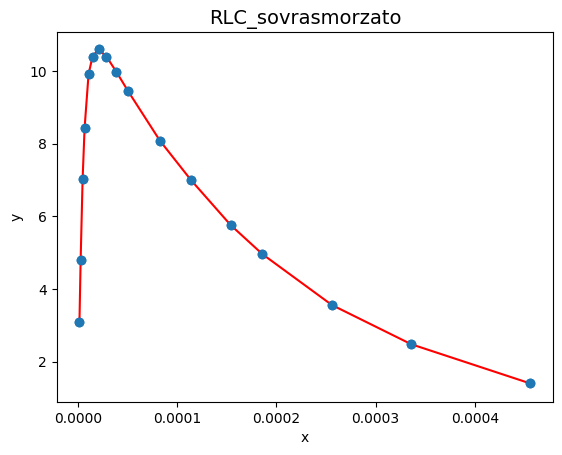

In [147]:
fig, ax = plt.subplots (nrows = 1, ncols = 1) # crea il grafico
ax.set_title ('RLC_sovrasmorzato', size=14)
ax.set_xlabel ('x')
ax.set_ylabel ('y')
ax.errorbar (t3_fit, V3_fit, xerr = 0.0, yerr = err___tot, linestyle = 'None', marker = 'o') #disegna punti con errori
ax.plot (t3_fit, V3_fit, color='red', label='sin(x)') # disegna grafico normale
ax.scatter(t3_fit, V3_fit, marker = 'o') # disegna solo i punti

In [148]:
least_square = LeastSquares(t3_fit, V3_fit, err___tot, RLC_sovra)

my_minuit = Minuit(least_square, s1=0, s2=0, V0=0)
my_minuit.limits['s1'] = (-1e2, -1e1)
my_minuit.limits['s2'] = (-1e9, -1e7)
my_minuit.limits['V0'] = (4,6)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

s1_fit = my_minuit.values['s1']
s1_err = my_minuit.errors['s1']
s2_fit = my_minuit.values['s2']
s2_err = my_minuit.errors['s2']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  3984500.342742297
value of the number of degrees of freedom:  14.0
associated p-value:  0.0
V0 = 6.000000e+00 +/- 4.326948e-04
s1 = -1.000000e+02 +/- 7.240815e-03
s2 = -9.999907e+08 +/- 9.828143e+08
┌────┬───────────────────────────────────────────┐
│    │            V0            s1            s2 │
├────┼───────────────────────────────────────────┤
│ V0 │      6.79e-14             0 -399.61207e-9 │
│ s1 │             0      2.74e-11 -32.092127e-6 │
│ s2 │ -399.61207e-9 -32.092127e-6      7.81e+13 │
└────┴───────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.985e+06 (χ²/ndof = 284607.2)│              Nfcn = 147              │
│ EDM = 4.69e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │  6.0000   │  0.0004   │            │            │    4    │    6    │       │
│ 1 │ s1   │ -100.000  │   0.007   │            │            │  -100   │   -10   │       │
│ 2 │ s2   │   -1e9    │    1e9    │            │            │ -1e+09  │ -1e+07  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────────────────┐
│    │            V0            s1            s2 │
├────┼───────────────────────────────────────────┤
│ V0 │      6.79e-14             0 -399.61207e-9 │
│ s1 │             0      2.74e-11 -32.092127e-6 │
│ s2 │ -399.61207e-9 -32.092127e-6      7.81e+13 │
└────┴───────────────────────────────────────────┘

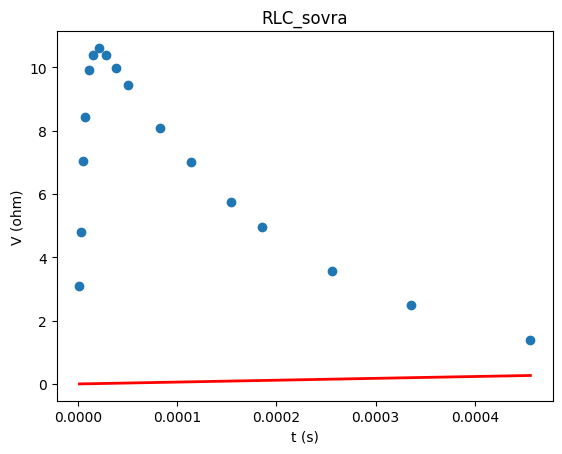

In [149]:
plot_fit(t3_fit,V3_fit, err___tot ,RLC_sovra, my_minuit, "RLC_sovra")
#plt.savefig("RL scarica.png")
plt.show()
#plt.close(fig)

In [150]:
def RLC_sotto(t,V0, alphass, omega_d):
    return V0 * (1 - np.exp(-alphass * t) * (np.cos(omega_d * t) + (alphass / omega_d) * np.sin(omega_d * t)))

In [153]:
with open('C2RLCsotto.txt') as input_file:
    t4list = []
    errt4list = []
    V4list = []
    errV4list = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        t4list.append(float(valori[0]))
        errt4list.append(float(valori[1]))
        V4list.append(float(valori[2]))
        errV4list.append(float(valori[3]))

t4_fit = np.array(t4list)
V4_fit = np.array(V4list)
errt4_fit = np.array(errt4list)
errV4_fit = np.array(errV4list)

err____tot=[]
for i in range(len(V4_fit)):
    err____tot.append(np.sqrt((errV4_fit[i]**2)+(errt4_fit[i]**2)))

print (err____tot)

['0.0000032', '0.00000001', '0.199', '0.04']
['0.0000112', '0.00000001', '0.439', '0.02']
['0.0000272', '0.00000001', '0.8', '0.01']
['0.0000432', '0.00000001', '0.96', '0.01']
['0.0000592', '0.00000001', '0.88', '0.01']
['0.0000752', '0.00000001', '0.679', '0.01']
['0.0000912', '0.00000001', '0.359', '0.04']
['0.000107', '0.00000001', '0.0396', '0.04']
['0.000123', '0.00000001', '-0.24', '0.04']
['0.000139', '0.00000001', '-0.4', '0.04']
['0.000147', '0.00000001', '-0.44', '0.04']
['0.000163', '0.00000001', '-0.4', '0.04']
['0.000187', '0.00000001', '-0.2', '0.04']
['0.000203', '0.00000001', '0', '0.04']
['0.000227', '0.00000001', '0.28', '0.04']
['0.000254', '0.00000001', '0.36', '0.02']
['0.000286', '0.00000001', '0.28', '0.02']
['0.000318', '0.00000001', '0.08', '0.02']
['0.000334', '0.00000001', '-0.04', '0.02']
['0.000366', '0.00000001', '-0.08', '0.01']
['0.000382', '0.00000001', '-0.04', '0.01']
['0.000406', '0.00000001', '0.04', '0.04']
['0.00043', '0.00000001', '0.12', '0.04'

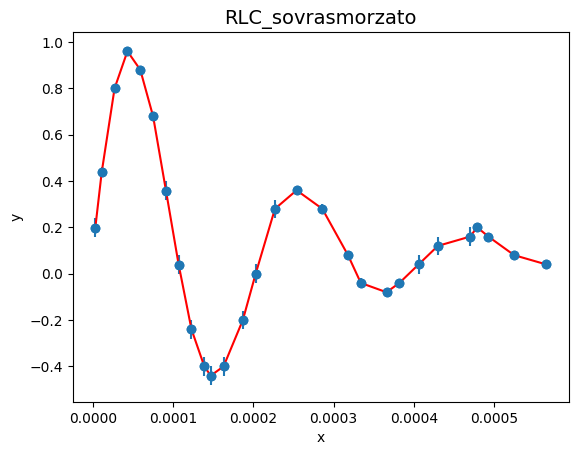

In [157]:
fig, ax = plt.subplots (nrows = 1, ncols = 1) # crea il grafico
ax.set_title ('RLC_sovrasmorzato', size=14)
ax.set_xlabel ('x')
ax.set_ylabel ('y')
ax.errorbar (t4_fit, V4_fit, xerr = 0.0, yerr = err____tot, linestyle = 'None', marker = 'o') #disegna punti con errori
ax.plot (t4_fit, V4_fit, color='red', label='sin(x)') # disegna grafico normale
ax.scatter(t4_fit, V4_fit, marker = 'o') # disegna solo i punti

In [156]:
least_square = LeastSquares(t4_fit, V4_fit, err____tot, RLC_sotto)

my_minuit = Minuit(least_square, alphass=0, omega_d=0, V0=0)
my_minuit.limits['alphass'] = (-1e2, -1e1)
my_minuit.limits['omega_d'] = (-1e9, -1e7)
my_minuit.limits['V0'] = (4,6)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

alphass_fit = my_minuit.values['alphass']
alphass_err = my_minuit.errors['alphass']
omega_d_fit = my_minuit.values['omega_d']
omega_d_err = my_minuit.errors['omega_d']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  1770786.8457793803
value of the number of degrees of freedom:  25.0
associated p-value:  0.0
V0 = 4.000000e+00 +/- 1.052886e-06
alphass = -1.000000e+01 +/- 6.398226e-03
omega_d = -1.000628e+07 +/- 2.801787e+00
┌─────────┬───────────────────────────────────────────┐
│         │            V0       alphass       omega_d │
├─────────┼───────────────────────────────────────────┤
│      V0 │      2.73e-25            -0 213.16478e-21 │
│ alphass │            -0      9.41e-20   -514.66e-18 │
│ omega_d │ 213.16478e-21   -514.66e-18          7.85 │
└─────────┴───────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.771e+06 (χ²/ndof = 70831.5)│              Nfcn = 82               │
│ EDM = 2.29e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0      │ 4.000000  │ 0.000001  │            │            │    4    │    6    │       │
│ 1 │ alphass │  -10.000  │   0.006   │            │            │  -100   │   -10   │       │
│ 2 │ omega_d │-10.0062786e6│0.0000028e6│            │            │ -1e+09  │ -1e+07  │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬───────────────────────────────────────────┐
│         │            V0       alphass       omega_d │
├─────────┼───────────────────────────────────────────┤
│      V0 │      2.73e-25            -0 213.16478e-21 │
│ alphass │            -0      9.41e-20   -514.66e-18 │
│ omega_d │ 213.16478e-21   -514.66e-18          7.85 │
└─────────┴───────────────────────────────────────────┘